# A/B Testing : Example 1

from here: https://github.com/renatofillinich/ab_test_guide_in_python/blob/master/AB%20testing%20with%20Python.ipynb


scenario : Let's imagine you work on the product team at a medium-sized online e-commerce business. The UX designer worked really hard on a new version of the product page, with the hope that it will lead to a higher conversion rate. The product manager (PM) told you that the current conversion rate is about 13% on average throughout the year, and that the team would be happy with an increase of 2%, meaning that the new design will be considered a success if it raises the conversion rate to 15%.

Before rolling out the change, the team would be more comfortable testing it on a small number of users to see how it performs, so you suggest running an A/B test on a subset of your user base users.(the data provided is for 21 days)

In [1]:
import os
import pandas as pd

In [2]:
data_path = "Experimentation/data/ab_testing_dataset_new"
print(os.listdir(data_path))

['ab_data.csv']


In [3]:
df = pd.read_csv(os.path.join(data_path, "ab_data.csv"))
print(df.shape)
df.head()

(294478, 5)


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [4]:
data_df = df.copy()

In [5]:
data_df.groupby(['group','landing_page']).agg({'user_id': 'nunique','converted': 'sum'}).reset_index()

,group,landing_page,user_id,converted
0,control,new_page,1928,234
1,control,old_page,145274,17489
2,treatment,new_page,145310,17264
3,treatment,old_page,1965,250


In [6]:
data_df = data_df[
    ((data_df['group'] == 'control') & (data_df['landing_page'] == 'old_page')) |
    ((data_df['group'] == 'treatment') & (data_df['landing_page'] == 'new_page'))
].reset_index(drop=True)

print(data_df.shape)
data_df.groupby(['group', 'landing_page']).agg({'user_id': 'nunique', 'converted': 'sum'}).reset_index()

(290585, 5)


,group,landing_page,user_id,converted
0,control,old_page,145274,17489
1,treatment,new_page,145310,17264


In [7]:
duplicates = data_df[data_df.duplicated('user_id', keep=False)]
print(f"Duplicate user_id rows: {len(duplicates)}")
print(f"Unique duplicated user_ids: {duplicates['user_id'].nunique()}")
duplicates.head(10)

Duplicate user_id rows: 2
Unique duplicated user_ids: 1


,user_id,timestamp,group,landing_page,converted
1876,773192,2017-01-09 05:37:58.781806,treatment,new_page,0
2862,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


In [8]:
data_df = data_df.drop_duplicates('user_id').reset_index(drop=True)

print(f"Rows after dedup: {data_df.shape[0]}")
print(f"Unique user_ids:  {data_df['user_id'].nunique()}")

Rows after dedup: 290584
Unique user_ids:  290584


In [9]:
data_df.groupby(['group', 'landing_page']).agg(
    unique_users=('user_id', 'nunique'),
    total_rows=('user_id', 'count'),
    conversions=('converted', 'sum')
).reset_index()

,group,landing_page,unique_users,total_rows,conversions
0,control,old_page,145274,145274,17489
1,treatment,new_page,145310,145310,17264


In [10]:
conversion_rates = data_df.groupby('group')['converted'].agg(
    users='count',
    conversions='sum'
).reset_index()


conversion_rates['conversion_rate'] = conversion_rates['conversions'] / conversion_rates['users']
conversion_rates

,group,users,conversions,conversion_rate
0,control,145274,17489,0.120386
1,treatment,145310,17264,0.118808


## Experiment Design

Before running any statistical test, we need to define the experiment upfront. Designing the experiment first ensures we don't p-hack (cherry-pick results) and that we collect enough data to trust the outcome.

### 1. Hypothesis
- **H₀**: The new page has no effect on conversion rate (CR_treatment = CR_control)
- **H₁**: The new page has a significant difference in conversion rate (CR_treatment ≠ CR_control)
- **Test type**: Two-tailed

### 2. Statistical Parameters
| Parameter | Value | Reason |
|---|---|---|
| Baseline conversion rate | 13% | Current average across the year |
| MDE (Minimum Detectable Effect) | 2% | Team considers +2pp a meaningful improvement |
| Target conversion rate | 15% | Baseline + MDE |
| Significance level (α) | 5% | Standard — 95% confidence |
| Power (1 - β) | 80% | Standard — 80% chance of detecting a true effect |

---

**α (Significance level) — Type I Error**

α is the probability of a **false positive** — concluding the new page works when it actually doesn't (rejecting H₀ when it's true).

Setting α = 0.05 means: *"I'm willing to accept a 5% chance of being wrong and shipping a change that has no real effect."*

How to read it here: after running the test, if our p-value < 0.05, we reject H₀ and conclude there is a statistically significant difference in conversion rates. If p-value ≥ 0.05, we fail to reject H₀.

**How to explain α to business stakeholders**

Avoid saying "p-value" or "Type I error" — instead frame it around risk and confidence:

> *"We ran this test with a 95% confidence threshold. That means if we see a difference, there's only a 5% chance it's a fluke caused by random variation in the data. In other words, we're 95% confident this result is real and not just noise."*

If the test is significant:
> *"The data gives us strong enough evidence that the new page performs differently. We're confident enough to act on this."*

If the test is not significant:
> *"We didn't see a strong enough signal to conclude the new page makes a difference. That doesn't mean it doesn't work — it means we can't tell from this data alone."*

---

**Power (1 - β) — Avoiding Type II Error**

β is the probability of a **false negative** — missing a real effect (failing to reject H₀ when it's actually false). Power = 1 - β is the probability of correctly detecting a true effect when one exists.

Setting Power = 0.80 means: *"If the new page genuinely improves conversion by 2pp, we have an 80% chance of detecting it. There's a 20% chance we miss it even if it's real."*

Power is directly tied to sample size — the more users you collect, the more power you have to detect smaller effects. Running a test with too few users means low power, and you risk missing a real improvement.

**How to explain Power to business stakeholders**

> *"We designed this test to have an 80% chance of catching a real improvement if it exists. That's the industry standard. Think of it like a medical test — even a good test occasionally misses a real condition. The 20% miss rate is a known, accepted trade-off. If we wanted to catch even smaller effects, we'd need to run the test longer."*

If the test comes back inconclusive:
> *"This doesn't necessarily mean the new page doesn't work. It's possible the effect is smaller than what we designed the test to detect. We could re-run with a larger sample if we want to be more sensitive."*

---

### 3. Sample Size
Using the baseline rate, MDE, α, and power we calculate the minimum number of users needed per group.

### 4. Test Duration
Based on the required sample size and daily traffic, how many days the test needs to run.

---

### α vs Power — What's the difference?

Think of it like a **court case**. The defendant is either guilty or innocent. You have two ways to get it wrong:

**α — False positive (Type I error)**
You convict an **innocent** person.
→ In our test: you conclude the new page works, but it actually doesn't.
→ α = 5% means you accept a 5% chance of this mistake.

**β — False negative (Type II error)**
You let a **guilty** person go free.
→ In our test: the new page actually works, but you missed it.
→ β = 20% means there's a 20% chance of this mistake.

**Power = 1 - β**
The chance you correctly convict the guilty person.
→ Power = 80% means 80% chance you correctly detect the real effect.

---

**Confidence level vs α**

These are the same number, just flipped:
- α = 5% → you accept a 5% chance of being wrong
- Confidence = 95% → you're 95% sure you're right

Same thing, different framing.

---

**In business terms**

| | What goes wrong | Business consequence |
|---|---|---|
| **α too high** | You ship changes that don't actually work | Wasted engineering effort, cluttered product, eroded trust in experimentation |
| **Power too low** | You kill features that actually work | Missed revenue, missed user improvements, good ideas get shelved |

> **α** is about **not wasting resources on things that don't work.**
> **Power** is about **not throwing away things that do work.**

A team that only cares about α ends up very conservative — they rarely ship false positives, but they also miss a lot of real wins. A team that only cares about power runs underpowered tests and ships noise. You need both.

---

**Why do we need both?**

Because they protect against **opposite mistakes** — and you can't just optimize one:

- If you set α very low (e.g. 1%) → you're very strict about false alarms, but it becomes much harder to detect real effects → **power drops**
- If you want high power → you need more users → the test runs longer and costs more
- If you collect too few users → power is low → you might miss a real improvement and kill a winning feature

Both are set **upfront, before the experiment runs**, as a deliberate trade-off between the two types of error. That's why sample size calculation exists — it finds the minimum number of users needed to satisfy both α and power at the same time.

---

### 3. Sample Size Calculation

We need to calculate the minimum number of users per group before running the test. Collecting too few users means low power (missing real effects). Collecting too many wastes time and money.

The formula for a two-proportion z-test is:

```
n = (z_α/2 + z_β)² × (p1(1-p1) + p2(1-p2)) / (p1 - p2)²
```

Where:
- **z_α/2** = 1.96 — z-score for α = 0.05, two-tailed
- **z_β** = 0.84 — z-score for power = 80%
- **p1** = 0.13 — baseline conversion rate (control)
- **p2** = 0.15 — target conversion rate (treatment)
- **(p1 - p2)** = MDE = 0.02

We'll use `statsmodels` to compute this directly.

**Absolute vs Relative MDE**

MDE can be expressed two ways:

- **Absolute MDE** — the raw percentage point difference: 15% - 13% = **2pp**
- **Relative MDE** — the lift relative to baseline: 2pp / 13% = **15.4% relative lift**

Relative MDE is more common in industry because it scales with your baseline — a 2pp lift means something very different on a 13% baseline vs a 50% baseline.

**The formula always takes absolute values** (p1 and p2 as raw proportions). Relative MDE is just a communication tool — convert it to absolute before plugging into any formula:

```python
# Starting from relative MDE
p2 = p1 * (1 + relative_mde)   # e.g. 0.13 * 1.10 = 0.143

# Starting from absolute MDE (what we have here)
p2 = 0.15                       # directly into the formula
```

In [11]:
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

p1 = 0.13  # baseline conversion rate
p2 = 0.15  # target conversion rate
alpha = 0.05
power = 0.80

effect_size = proportion_effectsize(p1, p2)
analysis = NormalIndPower()
sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
sample_size = int(sample_size) + 1

print(f"Baseline conversion rate : {p1:.0%}")
print(f"Target conversion rate   : {p2:.0%}")
print(f"MDE                      : {p2 - p1:.0%}")
print(f"Effect size (Cohen's h)  : {effect_size:.4f}")
print()
print(f"Required sample size per group : {sample_size:,}")
print(f"Total users required           : {sample_size * 2:,}")

Baseline conversion rate : 13%
Target conversion rate   : 15%
MDE                      : 2%
Effect size (Cohen's h)  : -0.0577

Required sample size per group : 4,720
Total users required           : 9,440


---

### 4. Test Duration

Now that we know the required sample size, we check:
1. Does the dataset have enough users per group?
2. How many days of traffic would be needed to reach that sample size?

In [12]:
data_df['timestamp'] = pd.to_datetime(data_df['timestamp'])

# Users per group in the dataset
control_n   = data_df[data_df['group'] == 'control'].shape[0]
treatment_n = data_df[data_df['group'] == 'treatment'].shape[0]

print(f"Required per group : {sample_size:,}")
print(f"Control users      : {control_n:,}  {'✓' if control_n >= sample_size else '✗ not enough'}")
print(f"Treatment users    : {treatment_n:,}  {'✓' if treatment_n >= sample_size else '✗ not enough'}")

# Daily traffic
experiment_days = (data_df['timestamp'].max() - data_df['timestamp'].min()).days
total_users     = data_df.shape[0]
daily_traffic   = total_users / experiment_days

print(f"\nExperiment ran for : {experiment_days} days")
print(f"Total users        : {total_users:,}")
print(f"Daily traffic      : {daily_traffic:,.0f} users/day")

# Days needed to reach required sample size
days_needed = (sample_size * 2) / daily_traffic
print(f"\nDays needed to reach required sample size : {days_needed:.1f} days")

Required per group : 4,720
Control users      : 145,274  ✓
Treatment users    : 145,310  ✓

Experiment ran for : 21 days
Total users        : 290,584
Daily traffic      : 13,837 users/day

Days needed to reach required sample size : 0.7 days


In [13]:
# normally we do not do this lol - we run the test and get the resutls but since we have the results we are kind 
# of simulating this the get the results
sample_size = 4720

control_sample   = data_df[data_df['group'] == 'control'].sample(n=sample_size, random_state=22)
treatment_sample = data_df[data_df['group'] == 'treatment'].sample(n=sample_size, random_state=22)

sample_df = pd.concat([control_sample, treatment_sample]).reset_index(drop=True)

print(f"Control sample   : {control_sample.shape[0]:,}")
print(f"Treatment sample : {treatment_sample.shape[0]:,}")
print(f"Total sample     : {sample_df.shape[0]:,}")
sample_df.groupby('group')['converted'].agg(users='count', conversions='sum').assign(
    conversion_rate=lambda x: x['conversions'] / x['users']
)

Control sample   : 4,720
Treatment sample : 4,720
Total sample     : 9,440


,users,conversions,conversion_rate
group,,,
control,4720,568,0.120339
treatment,4720,556,0.117797


---

### Normality Check — Success-Failure Condition

For a conversion rate A/B test, the individual observations are binary (0 or 1) — Bernoulli distributed by definition, never normal. **We don't check normality of the raw data.**

What needs to be approximately normal is the **sampling distribution of p̂** (the conversion rate). The CLT guarantees this when the sample is large enough — checked via the success-failure condition:

```
n × p̂ > 10        → enough conversions (successes)
n × (1 - p̂) > 10  → enough non-conversions (failures)
```

If both pass, the z-test is valid.

In [14]:
control_conv   = control_sample['converted'].sum()
control_n      = len(control_sample)
control_p      = control_conv / control_n

treatment_conv = treatment_sample['converted'].sum()
treatment_n    = len(treatment_sample)
treatment_p    = treatment_conv / treatment_n

print("Control:")
print(f"  n × p̂       = {control_n * control_p:.1f}  → {'✓' if control_n * control_p > 10 else '✗'}")
print(f"  n × (1-p̂)   = {control_n * (1 - control_p):.1f}  → {'✓' if control_n * (1 - control_p) > 10 else '✗'}")

print("\nTreatment:")
print(f"  n × p̂       = {treatment_n * treatment_p:.1f}  → {'✓' if treatment_n * treatment_p > 10 else '✗'}")
print(f"  n × (1-p̂)   = {treatment_n * (1 - treatment_p):.1f}  → {'✓' if treatment_n * (1 - treatment_p) > 10 else '✗'}")

Control:
  n × p̂       = 568.0  → ✓
  n × (1-p̂)   = 4152.0  → ✓

Treatment:
  n × p̂       = 556.0  → ✓
  n × (1-p̂)   = 4164.0  → ✓


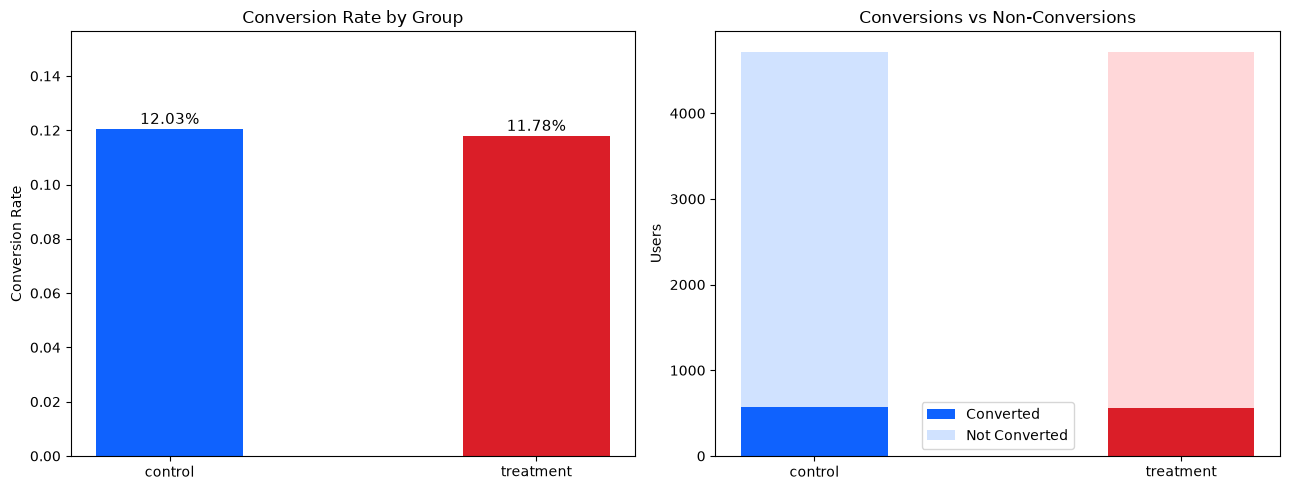

In [15]:
import matplotlib.pyplot as plt

# Conversion rates per group
summary = sample_df.groupby('group')['converted'].agg(
    users='count', conversions='sum'
).reset_index()
summary['conversion_rate'] = summary['conversions'] / summary['users']
summary['non_converted']   = summary['users'] - summary['conversions']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Conversion rate bar chart ---
colors = ['#0f62fe', '#da1e28']
bars = axes[0].bar(summary['group'], summary['conversion_rate'], color=colors, width=0.4)
axes[0].set_title("Conversion Rate by Group")
axes[0].set_ylabel("Conversion Rate")
axes[0].set_ylim(0, summary['conversion_rate'].max() * 1.3)

for bar, val in zip(bars, summary['conversion_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{val:.2%}", ha='center', fontsize=11)

# --- Plot 2: Stacked bar — converted vs not converted ---
axes[1].bar(summary['group'], summary['conversions'],    color=colors, width=0.4, label='Converted')
axes[1].bar(summary['group'], summary['non_converted'],  color=['#d0e2ff', '#ffd7d9'], width=0.4,
            bottom=summary['conversions'], label='Not Converted')
axes[1].set_title("Conversions vs Non-Conversions")
axes[1].set_ylabel("Users")
axes[1].legend()

plt.tight_layout()
plt.show()

## running the test ; hypothesis testing


Step 1 — Extract the numbers you need
  - conversions and users for control
  - conversions and users for treatment

  Step 2 — Run the two-proportion z-test
  - Use proportions_ztest from statsmodels
  - Pass in [control_conv, treatment_conv] and [control_n,
  treatment_n]
  - Set alternative='two-sided'
  - Get back z-statistic and p-value

  Step 3 — Compare p-value to α
  - If p-value < 0.05 → reject H₀
  - If p-value ≥ 0.05 → fail to reject H₀

  Step 4 — Calculate lift
  - lift = (treatment_rate - control_rate) / control_rate *
  100

  Step 5 — Calculate confidence interval
  - 95% CI on the difference in proportions
  - Use proportion_confint or compute manually using the
  standard error

  Step 6 — Interpret and conclude
  - State what the result means in plain English
  - Is it statistically significant?
  - Is the lift practically meaningful?

In [16]:
## step 1
sample_df.groupby('group')['converted'].agg(users='count', conversions='sum').assign(
    conversion_rate=lambda x: x['conversions'] / x['users']
)

,users,conversions,conversion_rate
group,,,
control,4720,568,0.120339
treatment,4720,556,0.117797


In [17]:
## step 2
from statsmodels.stats.proportion import proportions_ztest

conversions = [control_conv, treatment_conv]
n_obs       = [control_n, treatment_n]

print(f"Control conversions   : {control_conv:,} / {control_n:,}  → {control_p:.2%}")
print(f"Treatment conversions : {treatment_conv:,} / {treatment_n:,}  → {treatment_p:.2%}")


z_stat, p_value = proportions_ztest(conversions, n_obs, alternative='two-sided')
                  
print(f"Z-statistic : {z_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

Control conversions   : 568 / 4,720  → 12.03%
Treatment conversions : 556 / 4,720  → 11.78%
Z-statistic : 0.3814
P-value     : 0.7029


In [18]:
## step 3 : comapring p to alpha 
if p_value < alpha:
    print(f"Reject the null hypothesis (p < {alpha})")
    print("There is a statistically significant difference between the two groups.")
else:
    print(f"Fail to reject the null hypothesis (p >= {alpha})") 
    print("There is no statistically significant difference between the two groups.")


Fail to reject the null hypothesis (p >= 0.05)
There is no statistically significant difference between the two groups.


In [19]:
## step 4 : calculate lift 
lift = (treatment_p - control_p) / control_p
print(f"Lift: {lift:.2%}")  

Lift: -2.11%


In [22]:
## step 5 calculate confidence interval for the difference in conversion rates
import numpy as np
from statsmodels.stats.proportion import confint_proportions_2indep
  

ci_lower, ci_upper = confint_proportions_2indep(
      treatment_conv, treatment_n,
      control_conv, control_n,
      method='wald'
  )

print(f"95% CI on difference: ({ci_lower:.4f},{ci_upper:.4f})")



95% CI on difference: (-0.0156,0.0105)


In [23]:
import numpy as np
from scipy import stats

diff = treatment_p - control_p

se = np.sqrt(
      (control_p * (1 - control_p) / control_n) +
      (treatment_p * (1 - treatment_p) / treatment_n)
  )

z_critical = stats.norm.ppf(1 - 0.05/2)  # 1.96 for 95% CI, two-tailed

ci_lower = diff - z_critical * se
ci_upper = diff + z_critical * se

print(f"Difference : {diff:.4f}")
print(f"95% CI     : ({ci_lower:.4f}, {ci_upper:.4f})")

Difference : -0.0025
95% CI     : (-0.0156, 0.0105)


---

## Visualising the Results

The chart below combines everything into one view.

**How to read it:**

| Element | Colour | What it tells you |
|---|---|---|
| Red shaded tails | Red | Rejection region — if z lands here, p < α and we reject H₀ |
| Blue shaded area | Blue | P-value area — the probability of seeing a z this extreme or more under H₀ |
| Dashed blue lines | Blue | Observed z-statistic (±0.38) — far from the red tails, deep in the "do-nothing" zone |
| Dotted red lines | Red | Critical z (±1.96) — the threshold that divides "reject" from "fail to reject" |
| Purple bar (below) | Purple | 95% CI on the difference (Treatment − Control); annotated with the actual difference values |
| Red ✕ on CI bar | Red | Where H₀ sits (diff = 0); the CI crosses it, so we can't rule out zero difference |

**Interpreting the result:**

- **z = 0.38** lands well inside the curve, nowhere near the rejection tails → the signal is weak.
- **p = 0.70** >> α = 0.05 → we fail to reject H₀. There is no statistically significant difference.
- **95% CI = (−0.0156, +0.0105)** straddles zero. This means zero difference is a plausible true value — we cannot say the new page lifted or hurt conversion.
- The point estimate is actually slightly *negative* (treatment converted 0.25pp *less*), but the CI is wide enough that this could easily be noise.

**Bottom line:** The new page shows no meaningful change in conversion rate. Given the sample was more than large enough (~4,700 per group vs. the 4,720 required), this is a genuine null — not an underpowered test. The team should not ship the new page based on this data.

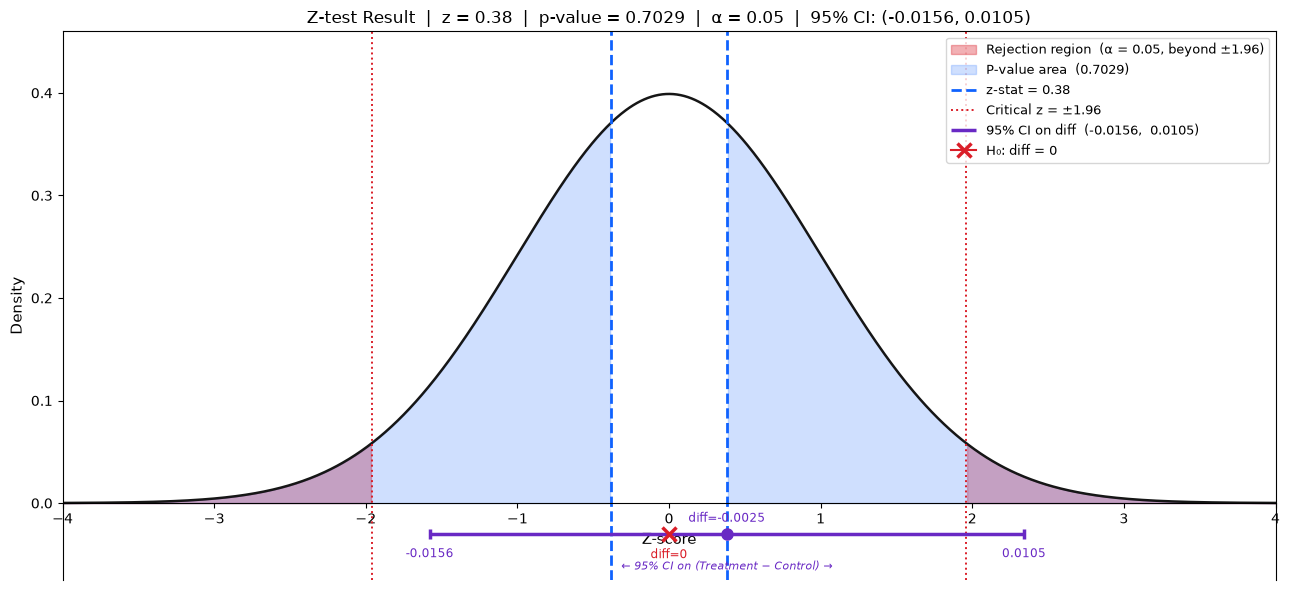

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Unpooled SE — same formula used for the CI
se = np.sqrt(
    (control_p * (1 - control_p) / control_n) +
    (treatment_p * (1 - treatment_p) / treatment_n)
)

# CI bounds expressed in z-score space so they sit on the same axis.
# z_stat = (control - treatment) / SE_pooled ≈ (control - treatment) / se
# → ci bounds in z-space: z_stat ± z_critical  (always ≈ ±1.96 for 95% CI)
z_critical  = stats.norm.ppf(1 - alpha / 2)   # 1.96
ci_lower_z  = z_stat - z_critical             # left  whisker in z-space
ci_upper_z  = z_stat + z_critical             # right whisker in z-space
diff        = treatment_p - control_p         # point estimate (negative here)

fig, ax = plt.subplots(figsize=(13, 6))

# ── Normal curve ──
x = np.linspace(-4, 4, 1000)
ax.plot(x, stats.norm.pdf(x), color='#161616', linewidth=1.8)

# ── Rejection regions (red) ──
for x_tail in [x[x <= -z_critical], x[x >= z_critical]]:
    lbl = f'Rejection region  (α = {alpha}, beyond ±{z_critical:.2f})' if x_tail[0] < 0 else '_'
    ax.fill_between(x_tail, stats.norm.pdf(x_tail), color='#da1e28', alpha=0.35, label=lbl)

# ── P-value area (blue) ──
for x_tail in [x[x <= -abs(z_stat)], x[x >= abs(z_stat)]]:
    lbl = f'P-value area  ({p_value:.4f})' if x_tail[0] < 0 else '_'
    ax.fill_between(x_tail, stats.norm.pdf(x_tail), color='#0f62fe', alpha=0.20, label=lbl)

# ── Observed z-statistic ──
ax.axvline( z_stat, color='#0f62fe', linewidth=2,   linestyle='--', label=f'z-stat = {z_stat:.2f}')
ax.axvline(-z_stat, color='#0f62fe', linewidth=2,   linestyle='--')

# ── Critical value boundaries ──
ax.axvline( z_critical, color='#da1e28', linewidth=1.4, linestyle=':',
           label=f'Critical z = ±{z_critical:.2f}')
ax.axvline(-z_critical, color='#da1e28', linewidth=1.4, linestyle=':')

# ── 95% CI bar (purple) below the curve ──
ci_y = -0.03

# Horizontal span and end caps
ax.hlines(ci_y, ci_lower_z, ci_upper_z, color='#6929c4', linewidth=2.5,
          label=f'95% CI on diff  ({ci_lower:.4f},  {ci_upper:.4f})')
ax.vlines([ci_lower_z, ci_upper_z], ci_y - 0.005, ci_y + 0.005,
          color='#6929c4', linewidth=2.5)

# Point estimate dot
ax.plot(z_stat, ci_y, 'o', color='#6929c4', markersize=8, zorder=5)

# Null-hypothesis marker (diff = 0 → z = 0)
ax.plot(0, ci_y, marker='x', color='#da1e28', markersize=10,
        markeredgewidth=2.5, zorder=5, label='H₀: diff = 0')

# Annotations: show the corresponding difference values below the CI bar
ax.text(ci_lower_z,  ci_y - 0.014, f'{ci_lower:.4f}',
        ha='center', va='top', fontsize=8.5, color='#6929c4')
ax.text(ci_upper_z,  ci_y - 0.014, f'{ci_upper:.4f}',
        ha='center', va='top', fontsize=8.5, color='#6929c4')
ax.text(z_stat,      ci_y + 0.009, f'diff={diff:.4f}',
        ha='center', va='bottom', fontsize=8.5, color='#6929c4')
ax.text(0,           ci_y - 0.014, 'diff=0',
        ha='center', va='top', fontsize=8.5, color='#da1e28')
ax.text((ci_lower_z + ci_upper_z) / 2, ci_y - 0.026,
        '← 95% CI on (Treatment − Control) →',
        ha='center', va='top', fontsize=8, color='#6929c4', style='italic')

ax.set_ylim(-0.075, 0.46)
ax.set_xlim(-4, 4)
ax.set_xlabel('Z-score', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(
    f'Z-test Result  |  z = {z_stat:.2f}  |  p-value = {p_value:.4f}  |  α = {alpha}  |  '
    f'95% CI: ({ci_lower:.4f}, {ci_upper:.4f})',
    fontsize=12
)
ax.legend(fontsize=9, loc='upper right')
ax.spines['bottom'].set_position(('data', 0))

plt.tight_layout()
plt.show()

---

## Drawing Conclusions

Every A/B test conclusion works through the same four questions in order:

```
1. Is it statistically significant?   → p-value vs α
      └─ No  → Stop. Cannot conclude anything. Do not ship.
      └─ Yes → Continue.

2. What is the direction and size of the effect?   → lift, point estimate
      └─ Is the lift in the direction we wanted?
      └─ Is the magnitude large enough to matter?

3. Is the CI consistent with the effect?   → confidence interval
      └─ Does the CI exclude zero?  (Should, if p < α)
      └─ Does the CI exclude the MDE?  (If yes, even the optimistic end is below our bar)

4. Make a decision.
      └─ Significant + meaningful lift  → Ship
      └─ Significant + negative / tiny lift  → Do not ship
      └─ Not significant  → Do not ship (or re-run with more data if underpowered)
```

The code cell below runs through this logic automatically for any test result.

In [25]:
mde         = p2 - p1
is_sig      = p_value < alpha
lift_abs    = treatment_p - control_p
lift_rel    = lift_abs / control_p
ci_excl_0   = ci_lower > 0 or ci_upper < 0
ci_excl_mde = ci_upper < mde

sep = "─" * 56

print(sep)
print("  A/B TEST CONCLUSION REPORT")
print(sep)
print(f"  Metric     : Conversion rate")
print(f"  Control    : {control_p:.2%}  ({control_conv:,} / {control_n:,})")
print(f"  Treatment  : {treatment_p:.2%}  ({treatment_conv:,} / {treatment_n:,})")
print(sep)

# ── Step 1: Statistical significance ──
print(f"\n  Step 1 — Statistical significance")
print(f"    p-value = {p_value:.4f}   α = {alpha}")
print(f"    Significant? {'YES  ✓' if is_sig else 'NO   ✗'}")

# ── Step 2: Effect size ──
print(f"\n  Step 2 — Effect size")
print(f"    Absolute lift  : {lift_abs:+.4f}  ({lift_abs*100:+.2f} pp)")
print(f"    Relative lift  : {lift_rel:+.2%}")
print(f"    Direction      : {'positive ↑' if lift_abs > 0 else 'negative ↓'}")
print(f"    MDE target     : +{mde:.2%}  (+{mde*100:.0f} pp)")

# ── Step 3: Confidence interval ──
print(f"\n  Step 3 — Confidence interval  (95%)")
print(f"    CI             : ({ci_lower:.4f}, {ci_upper:.4f})")
print(f"    CI excludes 0? : {'YES' if ci_excl_0 else 'NO  — zero is a plausible true value'}")
print(f"    CI below MDE?  : {'YES — even best case is below our bar' if ci_excl_mde else 'NO'}")

# ── Step 4: Decision ──
print(f"\n{sep}")
print(f"  Step 4 — DECISION")
print(sep)

if is_sig and lift_abs > 0 and not ci_excl_mde:
    decision = "SHIP"
    reasons  = [
        f"Result is statistically significant (p = {p_value:.4f} < α = {alpha}).",
        f"Treatment lifted conversion by {lift_abs*100:+.2f} pp ({lift_rel:+.2%} relative) in the right direction.",
        f"CI upper bound ({ci_upper:.4f}) reaches the MDE — the effect is large enough to matter.",
    ]
elif is_sig and lift_abs <= 0:
    decision = "DO NOT SHIP"
    reasons  = [
        f"Result is statistically significant (p = {p_value:.4f} < α = {alpha}).",
        f"But the treatment performed worse — lift is {lift_abs*100:+.2f} pp ({lift_rel:+.2%} relative).",
        "Shipping would harm conversion. Roll back.",
    ]
elif is_sig and ci_excl_mde:
    decision = "DO NOT SHIP"
    reasons  = [
        f"Result is statistically significant (p = {p_value:.4f} < α = {alpha}).",
        f"But the effect is too small — lift is only {lift_abs*100:+.2f} pp vs MDE of +{mde*100:.0f} pp.",
        f"Even the optimistic end of the CI ({ci_upper:.4f}) falls short of the MDE. Not worth shipping.",
    ]
else:
    decision = "DO NOT SHIP"
    reasons  = [
        f"Not statistically significant — p = {p_value:.4f} is well above α = {alpha}.",
        f"The test was adequately powered ({sample_size:,} per group needed, {min(control_n, treatment_n):,} collected).",
        "This is a genuine null, not a power problem. The new page shows no real effect.",
    ]

print(f"\n  Verdict  :  {decision}\n")
for i, r in enumerate(reasons, 1):
    print(f"  Reason {i}  :  {r}")
print(f"\n{sep}")

────────────────────────────────────────────────────────
  A/B TEST CONCLUSION REPORT
────────────────────────────────────────────────────────
  Metric     : Conversion rate
  Control    : 12.03%  (568 / 4,720)
  Treatment  : 11.78%  (556 / 4,720)
────────────────────────────────────────────────────────

  Step 1 — Statistical significance
    p-value = 0.7029   α = 0.05
    Significant? NO   ✗

  Step 2 — Effect size
    Absolute lift  : -0.0025  (-0.25 pp)
    Relative lift  : -2.11%
    Direction      : negative ↓
    MDE target     : +2.00%  (+2 pp)

  Step 3 — Confidence interval  (95%)
    CI             : (-0.0156, 0.0105)
    CI excludes 0? : NO  — zero is a plausible true value
    CI below MDE?  : YES — even best case is below our bar

────────────────────────────────────────────────────────
  Step 4 — DECISION
────────────────────────────────────────────────────────

  Verdict  :  DO NOT SHIP

  Reason 1  :  Not statistically significant — p = 0.7029 is well above α = 0.05.
